# Статистика, кафедра МТС

## Cеминар 1

____________________

In [2]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.6)

%matplotlib inline

## Доверительные интервалы

Визуализируем доверительные интервалы для выборки из нормального распределения. Чтобы впоследствии можно было использовать для построения других интервалов, напишем функцию, которая строит интервалы для разных размеров выборки и, если нужно, наносит точки выборки на график.

In [3]:
def draw_confidence_interval(
    left, right, estimation=None, sample=None,
    ylim=(None, None), color_estimation='#FF3300', color_interval='#00CC66',
    color_sample='#0066FF', label_estimation='Оценка'
):
    """Рисует доверительный интервал и оценку в зависимости от размера выборки.

    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimation: оценки (в зависимости от n)
    :param sample: выборка
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценки
    :param color_interval: цвет интервала
    :param color_sample: цвет выборки
    :param label_estimation: подпись к графику
    """

    time = np.arange(len(left)) + 1

    assert len(time) == len(right)

    if not sample is None:
        plt.scatter(time, sample, alpha=0.3, color=color_sample,
                    s=40, label='Элемент выборки')
    if not estimation is None:
        plt.plot(time, estimation, color=color_estimation,
                 linewidth=2.5, label=label_estimation)

    plt.fill_between(time, left, right, alpha=0.25, color=color_interval)
    plt.legend(fontsize=16)
    plt.ylim(ylim)
    plt.xlabel('Размер выборки')
    plt.title('Зависимость доверительного интервала от размера выборки')
    plt.grid()

Рассмотрим выборку из распределения $\mathcal{N}(0, 1)$; построим точный доверительный интервал минимальной длины в параметрической модели $\mathcal{N}(\theta, 1)$.

Сгенерируем выборку $X_1, ... X_{100}$ и построим график доверительных интервалов уровня доверия $0.95$, вычисленных для всех подвыборок вида $X_1, ... X_i$, $1 \le i \le 100$.

Построим графики зависимости верхних и нижних границ интервала от размера выборки, используя написанную функцию.
Для вычисления квантилей у каждого распределения из `scipy.stats` будем использовать функцию `ppf`.

Доверительный интервал: $\left(\overline{X} - \frac{\sigma z_{(1+\alpha)/2}}{\sqrt{n}},
\overline{X} + \frac{\sigma z_{(1+\alpha)/2}}{\sqrt{n}}\right)$, где $\sigma = 1$, а $z_{\gamma}$ &mdash; $\gamma$-квантиль стандартного нормального распределения.

Пояснение:

С помощью центрирования и нормирования получаем $\eta = \sqrt{n} (\overline{X} - \theta) \sim N(0, 1)$.

Тогда $P\left(\overline{X} - \frac{z_{(1 + \alpha)/2}}{\sqrt{n}} < \theta < \overline{X} + \frac{z_{(1 + \alpha)/2}}{\sqrt{n}}\right)  = P(-z_{(1 + \alpha)/2} < \eta < z_{(1 + \alpha)/2}) = \alpha$

Таким образом, мы нашли точный доверительный интервал.

У стандартного нормального распределения график плотности симметричен относительно оси Oy и убывает на положительной полуоси. Поэтому наименьшую длину среди интервалов с одинаковым уровнем доверия имеет симметричный относительно нуля. Ему соответствует квантиль уровня $\frac{1 + \alpha}{2}$. Так как границы искомого доверителного интервала зависят линейно от границ этого отрезка, то чтобы получить доверительный интервал наименьшей длины, надо выбрать отрезок наименьшей длины. Ему соответствует квантиль уровня  $\frac{1 + \alpha}{2}$

_______________________________________________________________________________________________________________________

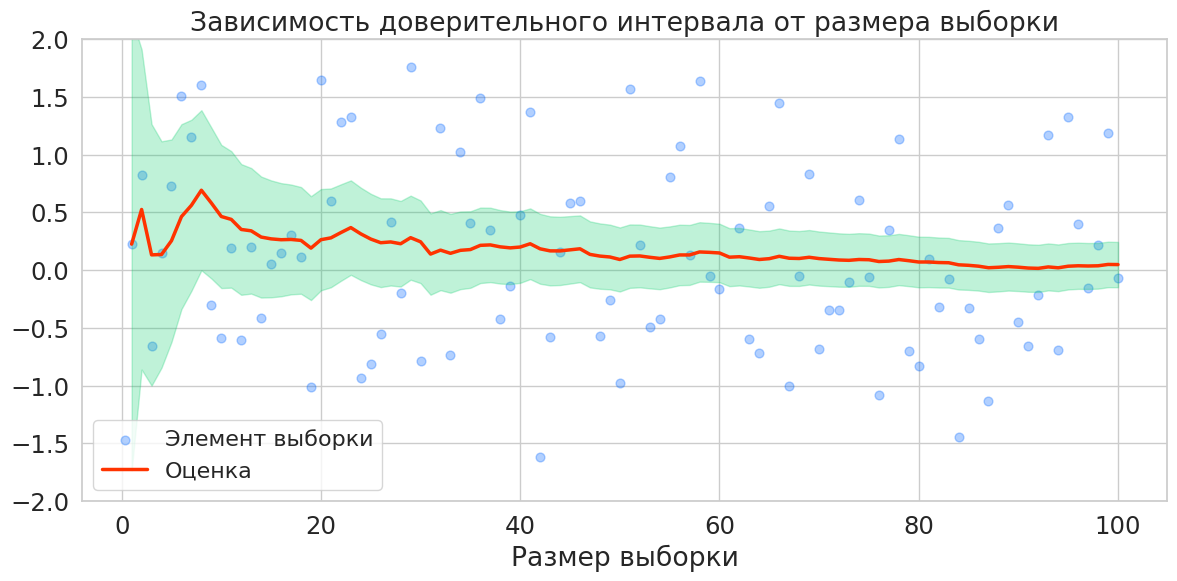

In [4]:
sample = sps.norm.rvs(size=100) # генерируем выборку
time = np.arange(len(sample)) + 1
alpha = 0.95

# вычисляем оценку и границы
estimation = sample.cumsum() / time
left = estimation + sps.norm.ppf((1 - alpha) / 2) / np.sqrt(time)
right = estimation + sps.norm.ppf((1 + alpha) / 2) / np.sqrt(time)

plt.figure(figsize=(14,6))
draw_confidence_interval(left, right, estimation, sample, ylim=(-2, 2))
plt.grid();

**Вывод:** по построенному графику видно, что с увеличением размера выборки длина доверительного интервала становится меньше, что неудивительно, так как мы получаем большее количество информации о распределении. Соответственно, сохранив степень уверенности 95%, мы можем давать более точную оценку. Иными словами, при фиксированном размере выборки мы можем сказать, что истинное значение параметра попадет в доверительный интервал с вероятностью 0.95, причем полученный график соответствуют теоретическим свойствам доверительных интервалов — истинное значение параметра действительно лежит в них (но в 5% случаев это может быть не так).

## Несмещенность оценок

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $\mathcal{N}(0, \sigma^2)$. Известно, что в качестве оценки параметра $\sigma^2$ можно использовать следующие оценки $S^2, \frac{n}{n-1}S^2$.

**Напоминание:** $S^2 := \frac{1}{n} \sum\limits_{i = 1}^{n} (X_i - \overline{X})^2 = \overline{X^2} - \overline{X}^2$

**Вопрос:** Какие из этих оценок являются несмещенными?

**Ответ:** $\frac{n}{n-1}S^2$.

$\mathsf{E}_\sigma S^2 = \mathsf{E}_\sigma \overline{X^2} - \mathsf{E}_\sigma \overline{X}^2$
= $\frac{1}{n}\mathsf{E}_\sigma \sum\limits_{i=1}^{n}X_i^2 - \frac{1}{n^2}\mathsf{E}_\sigma \sum\limits_{i=1}^{n} X_i^2 - \frac{1}{n^2}\sum\limits_{i \neq j} \mathsf{E}_\sigma X_i X_j$
= $\frac{n-1}{n}\mathsf{E}_\sigma X^2 - \frac{n(n-1)}{n^2} \mathsf{E}_\sigma X^2$
= $\frac{n-1}{n}\mathsf{D}_\sigma X$

$\Rightarrow$ $S^2$ &mdash; смещенная оценка, $\frac{n}{n-1}S^2$ &mdash; несмещенная оценка $\sigma^2$, ее также называют исправленной выборочной дисперсией.

Реализуем функции, вычисляющие оценки по набору выборок. У матрицы, заданной в виде `numpy.array` есть метод `var` вычисляющий выборочную дисперсию. Мы указываем аргумент `axis=-1`, чтобы указать, что дисперсию необходимо посчитать только по последней оси матрицы. Например, если у нас есть 500 выборок размера 100, которые заданы матрицей размера (500, 100), то такая функция посчитает выборочную дисперсию по каждой выборке и вернет 500 чисел. Аргумент `ddof` отвечает за поправку в нормирующем множителе, если он указан, то деление происходит на $n - ddof$.

In [5]:
def estimate_s2(X):
    ''' Смещенная оценка дисперсии '''
    return X.var(axis=-1)

def estimate_s2_corrected(X):
    ''' Несмещенная оценка дисперсии '''
    return X.var(axis=-1, ddof=1)

Зададим список оценок и разные параметры для отрисовки графика

In [6]:
estimators = [
    (estimate_s2, "$S^2$", "red", 0.0),
    (estimate_s2_corrected, "$\\frac{n}{n-1}S^2$", "green", 0.1)
]

Напишем функцию, которая для каждой оценки визуализирует разброс реализаций оценки и ее среднее значение.

In [7]:
def est_plot(distribution, estimators, sample_size, sample_count):
    '''
    Построение графика разброса реализаций оценок и их средних значений.

    distribution -- распределение формата scipy.stats
    estimators -- список оценок и параметров для отрисовки графиков
    sample_size -- размер выборок
    sample_count -- количество генерируемых выборок
    '''

    X = distribution.rvs(size=(sample_count, sample_size))

    plt.figure(figsize=(18, 0.7 * len(estimators)))
    for estimator, name, color, y in estimators:
        E = estimator(X)

        plt.scatter(E, np.zeros(sample_count) + y, alpha=0.1,
                    s=100, color=color, label=name)
        plt.scatter(E.mean(), y, marker='*', s=300,
                    color='w', edgecolors='black')

    plt.vlines(1, -1, 1, color='r')
    plt.title('Размер выборки = %d' % sample_size)
    plt.yticks([])
    plt.legend()
    plt.xlim((0.6, 1.4))
    plt.ylim((-0.1, 0.1 * len(estimators)))

Вызываем функцию для разных размеров выборок

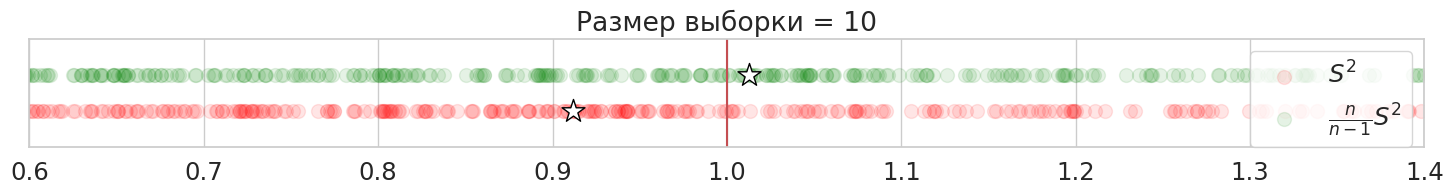

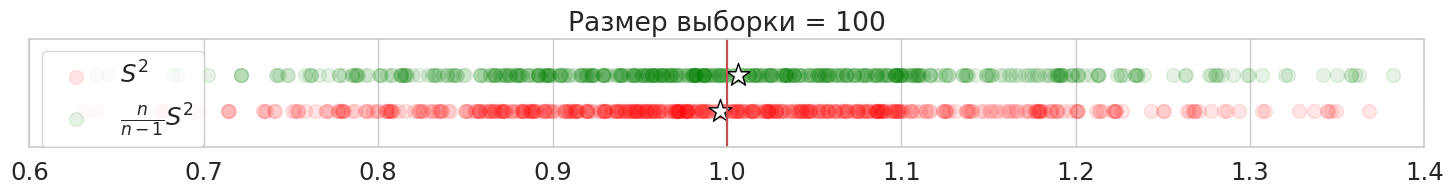

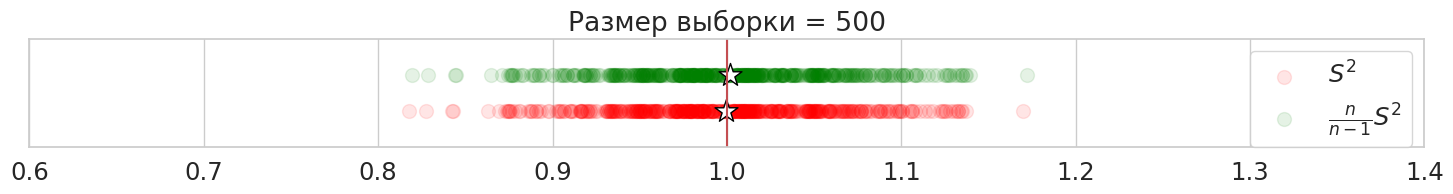

In [8]:
sample_size_list = (10, 100, 500)  # размеры выборок
sample_count = 500  # количество экспериментов

for sample_size in sample_size_list:
    est_plot(sps.norm, estimators, sample_size, sample_count)

**Вывод.** Несмещенность &mdash; свойство оценки в среднем быть равной параметру, который она оценивает. Иначе говоря, при бесконечном повторении эксперимента в среднем оценка будет равна истинному значению параметра.
Проведенные эксперименты подтверждают свойство несмещенности &mdash; среднее значение несмещенной оценки $\frac{n}{n-1}S^2$ оказалось примерно равно истинному значению параметра в отличии от смещенной оценки. Кроме того, можно заметить, что для смещенной оценки $S^2$ смещение уменьшается с ростом размера выборки, иначе говоря, она является *асимптотически несмещенной*.

В лабораторных работах скорректированные оценки используют, т.к. число опытов часто мало и $n$ нельзя считать достаточно большим. В таком случае отличие между несмещенными оценками и асимптотически несмещенными оценками становится существенным.

## Состоятельность и асимптотическая нормальность оценок (задание на семинар)

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $Exp(\theta)$. Как известно из теории, оценка $\widehat{\theta} = 1/\overline{X}$ является *состоятельной* и *асимтотически нормальной* оценкой параметра $\theta$ с асимптотической дисперсией $\theta^2$. Визуализируем данные свойства.

Зададим параметры эксперимента,

In [76]:
theta = 2  # истинное значение параметра
size = 300  # размер выборок
samples_count = 500  # количество выборок

Сгенерируйте множество выборок. Для этого передайте необходимые параметры при создании объекта `sps.expon`. Нужно правильно выставить параметр `scale`. Чтобы генерировать много выборок сразу, генерируйте сразу двумерный массив, передав пару в параметр `size`.

In [88]:
samples = sps.expon.rvs(size=(samples_count, size), scale=1/theta)

Вычислите оценку параметра $\theta$ для всех выборок, для каждого размера. Обязательно сделайте это без циклов.

In [107]:
estimations = 1 / samples.mean(axis=-1)

(500,)


Возьмите первую выборку и визуализируйте, как изменяется оценка в зависимости от размера выборки. Добавьте горизонтальную линию на график с координатой, равной правильной оценке. Не забудьте подписать оси и добавить легенду через `plt.legend`.

In [103]:
def draw_unbiased_estimation(
    estimation=None, sample=None, true_value=None,
    ylim=(None, None), color_estimation='#FF3300', color_interval='#00CC66',
    color_sample='#0066FF', label_estimation='Оценка', label_true_value='Истинное значение'
):
    """Рисует истинное значение и оценку в зависимости от размера выборки.

    :param estimation: массив оценок (в зависимости от n)
    :param sample: выборка
    :param true_value: истинное значение оценки
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет линии оценки
    :param color_interval: цвет линии истинного значения
    :param color_sample: цвет точек выборки
    :param label_estimation: подпись к линии оценки
    :param label_true_value: подпись к линии истинного значения
    """
    time = np.arange(len(sample)) + 1

    if sample is not None:
        plt.scatter(time, sample, alpha=0.3, color=color_sample,
                    s=40, label='Элемент выборки')
    if estimation is not None:
        plt.plot(time, estimation, color=color_estimation,
                 linewidth=2.5, label=label_estimation)
    if true_value is not None:
        plt.hlines(true_value, xmin=1, xmax=len(sample),
                   colors=color_interval, linestyles='dashed',
                   linewidth=2, label=label_true_value)

    plt.legend(fontsize=16)
    plt.ylim(ylim)
    plt.xlabel('Размер выборки')
    plt.title('Зависимость оценки от размера выборки')
    plt.grid()


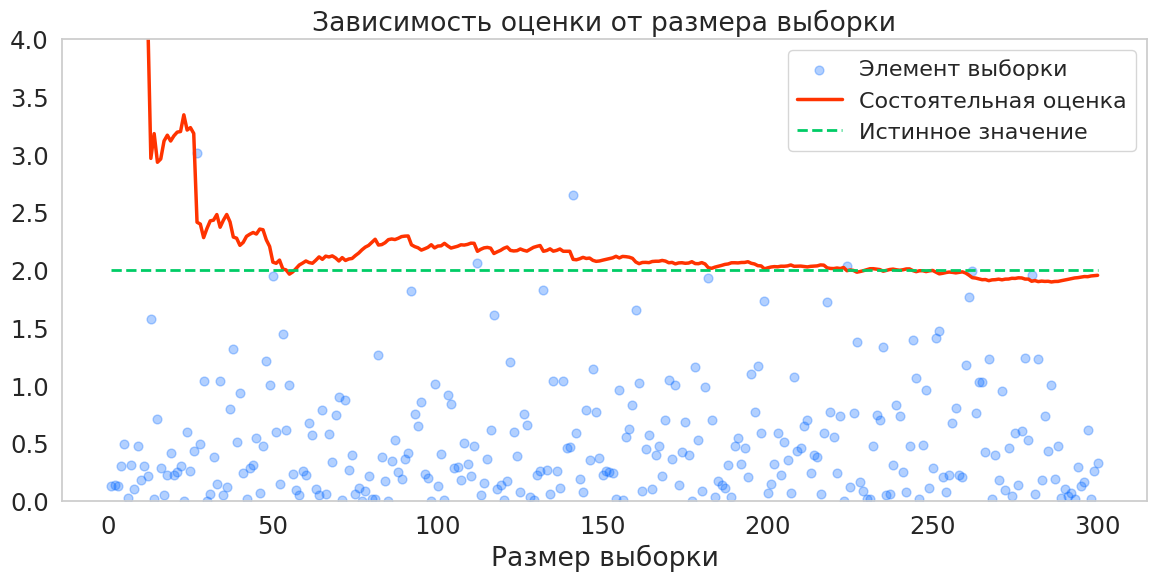

In [104]:
sample_0 = samples[0]
estimation_0 = np.arange(1, size + 1) / sample_0.cumsum()

plt.figure(figsize=(14,6))

draw_unbiased_estimation(
    estimation=estimation_0,
    sample=sample_0,
    true_value=theta,
    ylim=(0, 4),
    label_estimation='Состоятельная оценка',
    label_true_value='Истинное значение'
)

**Вывод.** Состоятельность оценки означает, что при увеличении объёма выборки оценка стремится к истинному значению параметра, который она оценивает. Проведённые эксперименты подтверждают свойство состоятельности оценки $\hat{\theta} = 1/\overline{X}$ — по мере роста размера выборки оценка приближается к истинному значению параметра $\theta = 2$. Это видно на графике: значения оценки стабилизируются и колебания вокруг истинного значения уменьшаются.

Кроме того, оценка является *асимптотически нормальной* с асимптотической дисперсией $\theta^2$. Это означает, что при больших $n$ распределение оценки $\hat{\theta}$ приближается к нормальному распределению с математическим ожиданием $\theta$ и дисперсией $\theta^2/n$.  В эксперименте можно наблюдать, как разброс значений оценки уменьшается при увеличении размера выборки, что подтверждает свойство асимптотической нормальности.

Таким образом, в практических задачах при достаточном объёме выборки можно использовать оценку $\hat{\theta}$, зная, что она будет близка к истинному значению параметра и её распределение можно приближать нормальным для целей построения доверительных интервалов и проверки гипотез.

Посмотрим, что будет происходить, если сгенерировать выборки много раз. Свойство сильной состоятельности говорит, что почти наверное траектория сойдётся к истинной оценке. Посмотрим, всегда ли это происходит на выборках нашего размера.

Свойство же асимптотической нормальности позволяет сказать, насколько большим может быть отклонение от истины. Мы можем сказать, что в пределе, то есть при достаточно больших размерах выборки, с вероятностью $> 0.95$ выполнено свойство

$$ \theta - \frac{2\sigma}{\sqrt(n)} < \widehat{\theta} < \theta + \frac{2\sigma}{\sqrt(n)}  $$

Здесь $\sigma^2$ - асимптотическая дисперсия

Вычислите границы интервала для полученных оценок

In [91]:
sigma = theta
left = theta - 2 * sigma / np.sqrt(np.arange(1, size + 1))
right = theta + 2 * sigma / np.sqrt(np.arange(1, size + 1))

Визуализируем для каждой выборки все оценки в зависимости от размера выборки. Добавляйте каждый график с прозрачностью `alpha=0.05`, чтобы замечать скопления кривых в одном месте.
Нанесите на график истинную оценку, а также границы интервала, в которых должны быть значения $\widehat{\theta}$ в пределе.

In [99]:
def draw_confidence_interval(
    left, right, estimations=None, time=None,
    ylim=(None, None), color_estimation='#0066FF', color_interval='#00CC66',
    alpha_estimation=0.05, label_interval='95% доверительный интервал'
):
    """Рисует доверительный интервал и оценки в зависимости  от размера выборки.

    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimations: массив оценок (несколько траекторий)
    :param time: массив размеров выборки
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценок
    :param color_interval: цвет интервала
    :param alpha_estimation: прозрачность линий оценок
    :param label_interval: подпись к доверительному интервалу
    """
    if time is None:
        time = np.arange(len(left)) + 1

    plt.fill_between(time, left, right, alpha=0.25, color=color_interval, label=label_interval)

    if estimations is not None:
        for estimation in estimations:
            plt.plot(time, estimation, color=color_estimation,
                     linewidth=1.5, alpha=alpha_estimation)

    plt.xlabel('Размер выборки')
    plt.ylabel('Оценка $\\hat{\\theta}$')
    plt.title('Зависимость оценок от размера выборки')
    plt.grid()
    plt.ylim(ylim)


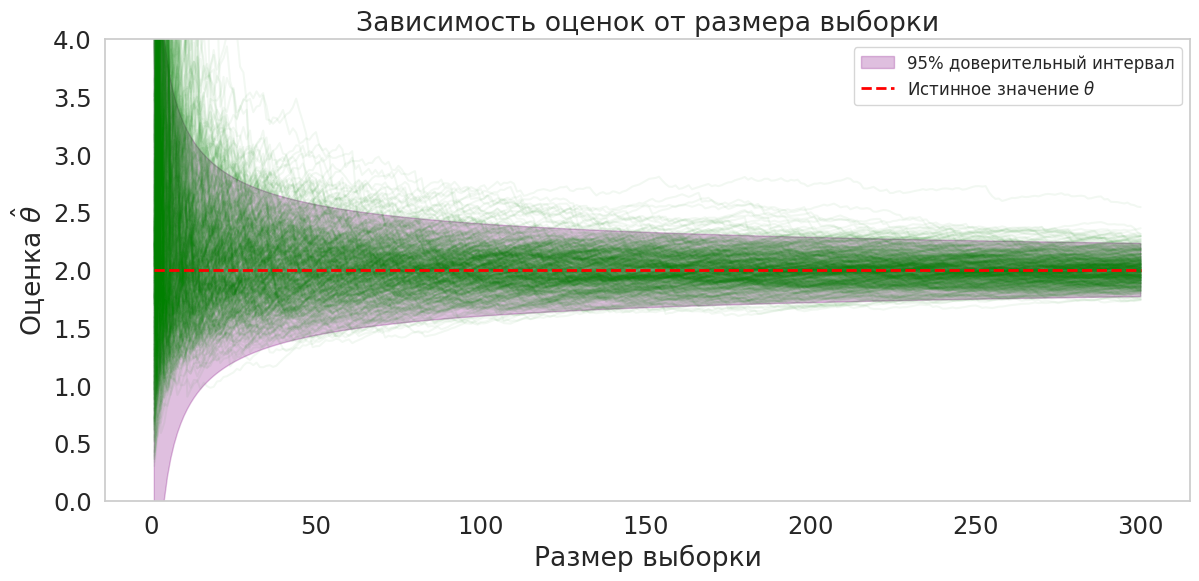

In [143]:
plt.figure(figsize=(14,6))
estimations = np.arange(1, size + 1) / samples.cumsum(axis=-1)

draw_confidence_interval(
    left=left,
    right=right,
    estimations=estimations,
    time=np.arange(1, size + 1),
    ylim=(0, 4),
    color_estimation='green',
    color_interval='purple',
    alpha_estimation=0.05
)


plt.hlines(theta, xmin=1, xmax=size, colors='red', linestyles='dashed', linewidth=2, label='Истинное значение $\\theta$')

plt.legend(fontsize=12)
plt.show()


**Вывод:** По мере увеличения размера выборки длина доверительного интервала уменьшается, так как мы получаем больше информации о параметре $\theta$. Зелёные линии представляют траектории оценок $\hat{\theta}$ для разных выборок, которые с ростом $n$ сходятся к истинному значению параметра (красная пунктирная линия).

Границы доверительного интервала (зелёная область) также сужаются, что подтверждает свойства состоятельности и асимптотической нормальности оценки. С вероятностью 95\% оценки находятся внутри этих границ. Таким образом, оценка $\hat{\theta}$ при увеличении объёма выборки становится более точной и надёжно приближает истинное значение $\theta$.


Приблизим этот график в области малых размеров выборки. Для этого ограничьте ось X размером выборки $30$. Как вы можете объянить непопадание траекторий в построенные границы?

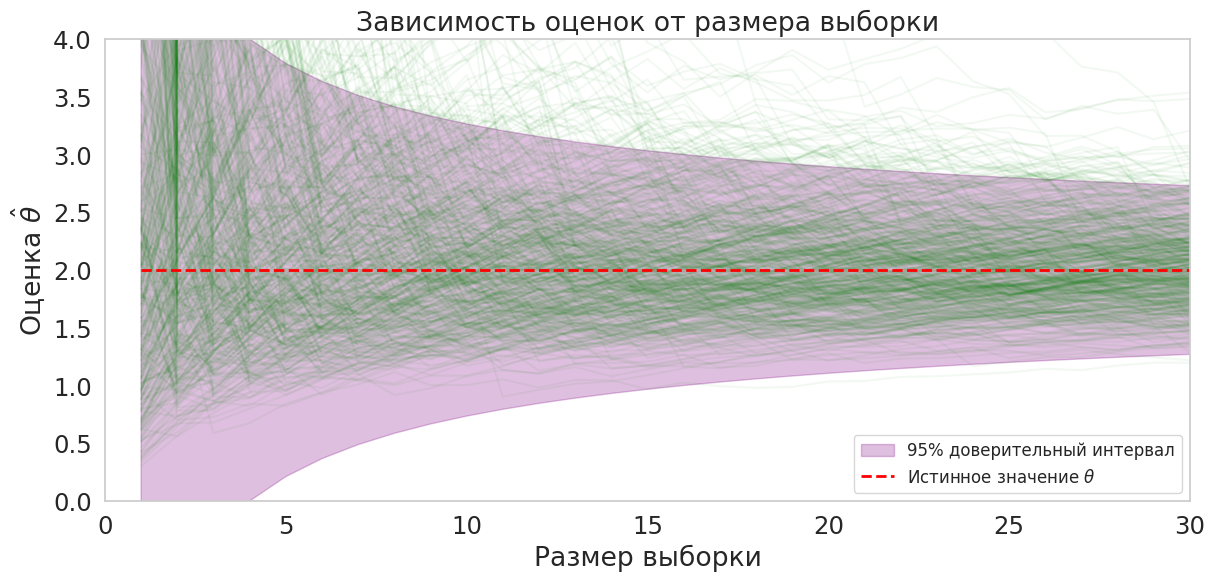

In [144]:
plt.figure(figsize=(14,6))

draw_confidence_interval(
    left=left,
    right=right,
    estimations=estimations,
    time=np.arange(1, size + 1),
    ylim=(0, 4),
    color_estimation='green',
    color_interval='purple',
    alpha_estimation=0.05
)

plt.hlines(theta, xmin=1, xmax=size, colors='red', linestyles='dashed', linewidth=2, label='Истинное значение $\\theta$')

plt.xlim(0, 30)

plt.legend(fontsize=12)
plt.show()


Непопадание траекторий оценок в границы доверительного интервала при малых размерах выборки объясняется высокой дисперсией оценок $\hat{\theta}$ на небольших $n$. В таких условиях выборочные оценки сильно флуктуируют, и асимптотическая нормальность ещё не начинает проявляться. По мере увеличения размера выборки дисперсия уменьшается, и оценки начинают попадать в границы интервала, что соответствует свойствам асимптотической нормальности.

Посмотрим также, как себя ведут величины
$$Z_n = \sqrt{n}\frac{\widehat{\theta} - \theta}{\theta},$$
распределение которых должно сходиться к стандартному нормальному.

Вычислите $Z_n$ для всех выборок и все размеров выборки без циклов.

In [150]:
Z_n = np.sqrt(n_array) * (estimations - theta) / theta

Визуализируйте траектории $Z_n$ для всех выборок, также добавляя графики с прозрачностью. Похоже ли распределение при большом размере выборки на нормальное?

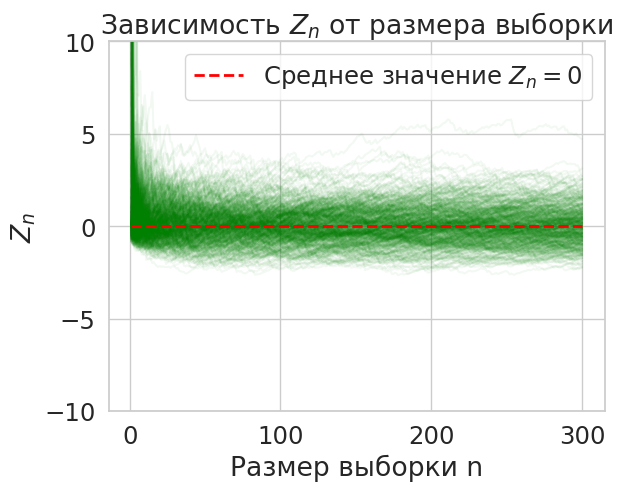

In [160]:
for i in range(samples_count):
    plt.plot(n_array, Z_n[i], color='green', alpha=0.05)

plt.ylim(-10, 10)

plt.hlines(0, xmin=1, xmax=size, colors='red', linestyles='dashed', linewidth=2, label='Среднее значение $Z_n = 0$')

plt.xlabel('Размер выборки n')
plt.ylabel('$Z_n$')
plt.title('Зависимость $Z_n$ от размера выборки')
plt.grid(True)
plt.legend()
plt.show()

**Вывод:** **Вывод:** По мере увеличения размера выборки $n$, значения $Z_n$ стабилизируются вокруг нуля, что соответствует ожидаемому поведению по свойствам асимптотической нормальности. На больших размерах выборки $Z_n$ распределены близко к стандартному нормальному распределению, что подтверждается схождением большинства траекторий к значению $Z_n = 0$ с небольшими отклонениями. Это указывает на то, что распределение $Z_n$ для больших выборок действительно сходится к нормальному распределению.

Для размера выборки 300 также постройте гистрограмму значений величин $Z_{300}$. Нанесите на график плотность стандартного нормального распределения (вычисляется с помощью `sps.norm.pdf`) и сделайте вывод.

In [ ]:
<...>